In [27]:
import numpy as np # numerical values
import pandas as pd # tables
import matplotlib.pyplot as plt # for plots


# Clinical Refernces Ranges and Values

# Database columns to clean labels for graphs/charts
CLEAN_LABELS = {
    "esi": "Acuity (ESI)",
    "triage_vital_hr": "Heart Rate",
    "triage_vital_sbp": "Systolic BP",
    "triage_vital_dbp": "Diastolic BP",
    "triage_vital_rr": "Resp Rate",
    "triage_vital_o2": "Oxygen Sat (SpO2)",
    "triage_vital_o2_device": "Supplemental oxygen",
    "triage_vital_temp": "Temperature (°F)",
    "triage_vital_temp_c": "Temperature (°C)",
    "triage_glucose": "Blood Glucose"
}

# Healthy Adult Ranges
NORMAL_RANGES = {
    "triage_vital_hr": (60, 100, "bpm"), 
    "triage_vital_sbp": (90, 140, "mmHg"),
    "triage_vital_dbp": (60, 90, "mmHg"), 
    "triage_vital_rr": (12, 20, "/min"),
    "triage_vital_o2": (95, 100, "%"), 
    "triage_vital_temp": (97.0, 99.5, "°F"), 
    "triage_vital_temp_c": (36.1, 37.5, "°C"), 
    "triage_glucose": (70, 140, "mg/dL")
}

# cutoffs for biologically possible values

PLAUSIBLE = {
    "age": (0, 120), "esi": (1, 5), 
    "triage_vital_hr": (20, 250), 
    "triage_vital_sbp": (50, 300),
    "triage_vital_dbp": (20, 200), 
    "triage_vital_rr": (4, 60), 
    "triage_vital_o2": (50, 100),
    "triage_vital_temp": (86, 110), 
    "triage_vital_temp_c": (30, 43.3), 
    "triage_glucose": (20, 800)
}

fam = classify_columns(df)
structured = [col for col in df.columns if not col.startswith("cc_")]

In [28]:
df = pd.read_csv("data/yaleemmlc_admissionprediction_triage.csv")
print(f"Loaded {df.shape[0]:,} ED encounters x {df.shape[1]} columns")
df.head()

Loaded 55,121 ED encounters x 226 columns


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,...,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


--- Missing Data Summary ---
0 out of 26 features have missing rows.



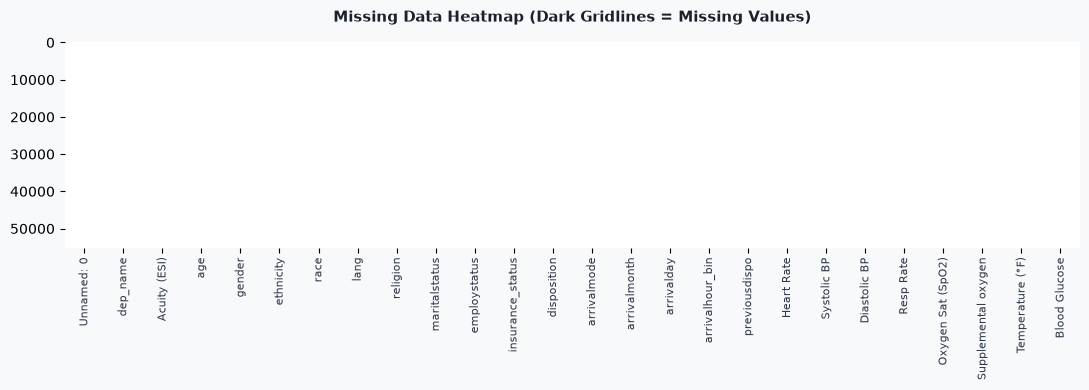


--- Data Types & ESI Target Counts ---
Unnamed: 0                  int64
dep_name                      str
esi                       float64
age                       float64
gender                        str
ethnicity                     str
race                          str
lang                          str
religion                      str
maritalstatus                 str
employstatus                  str
insurance_status              str
disposition                   str
arrivalmode                   str
arrivalmonth                  str
arrivalday                    str
arrivalhour_bin               str
previousdispo                 str
triage_vital_hr           float64
triage_vital_sbp          float64
triage_vital_dbp          float64
triage_vital_rr           float64
triage_vital_o2           float64
triage_vital_o2_device    float64
triage_vital_temp         float64
triage_glucose            float64
dtype: object

ESI Value Counts:
esi
1.0       77
2.0    17924
3.0    27010


In [29]:
# Checking for Missing Values
print("--- Missing Data Summary ---")
missing_fraction = df[structured].isna().sum() / len(df)
missing_percent = (missing_fraction * 100).round(1).sort_values(ascending=False)
cols_with_gaps = missing_percent[missing_percent > 0]

print(f"{len(cols_with_gaps)} out of {len(structured)} features have missing rows.\n")

# Plot missingness matrix using a clean dashboard layout
fig, ax = plt.subplots(figsize=(11, 4), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Black bars indicate NaN values
ax.imshow(df[structured].isna().values, aspect="auto", cmap="binary", interpolation="none")
ax.set_xticks(range(len(structured)))
ax.set_xticklabels([CLEAN_LABELS.get(c, c) for c in structured], rotation=90, fontsize=8, color="#2D3748")
ax.set_title("Missing Data Heatmap (Dark Gridlines = Missing Values)", fontsize=11, fontweight="bold", pad=15, color="#1A202C")
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print("\n--- Data Types & ESI Target Counts ---")
print(df[structured].dtypes)
print("\nESI Value Counts:")
print(df[TARGET].value_counts(dropna=False).sort_index())

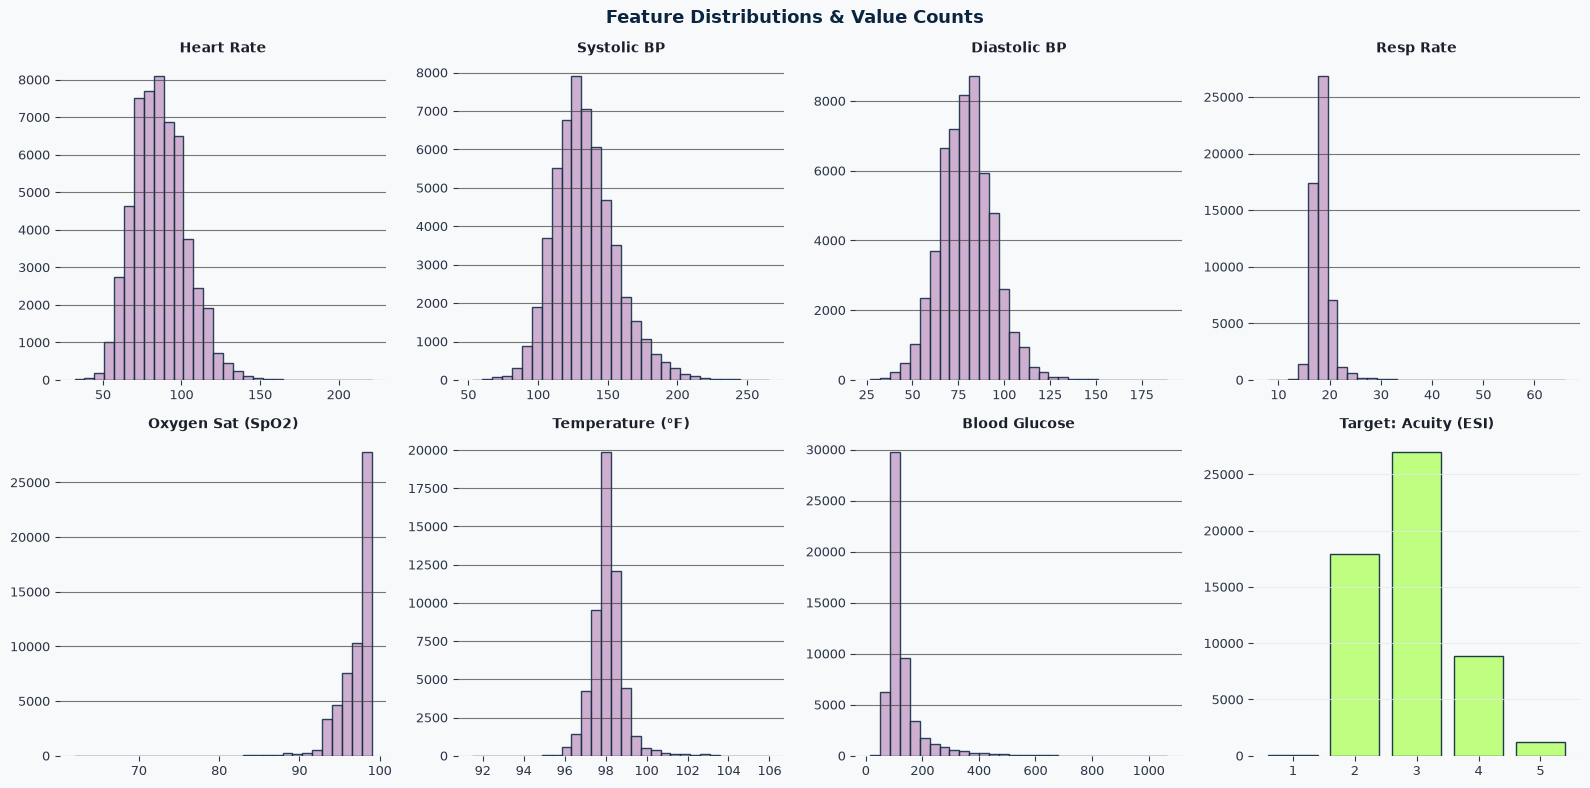


--- Demographics Value Counts ---

RACE:
{'White or Caucasian': 29435, 'Black or African American': 15963, 'Other': 9016, 'Patient Refused': 370, 'Asian': 175, 'Unknown': 76, 'American Indian or Alaska Native': 66, 'Native Hawaiian or Other Pacific Islander': 20}

ETHNICITY:
{'Non-Hispanic': 45142, 'Hispanic or Latino': 9888, 'Patient Refused': 56, 'Unknown': 35}

INSURANCE_STATUS:
{'Medicaid': 21427, 'Medicare': 17581, 'Commercial': 14056, 'Other': 1883, 'Self pay': 174}


In [30]:
# Plotting Histograms and Graphs
vitals = [v for v in fam["vitals"] if v in df.columns]

# Build a 2x4 grid for subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='#F8F9FA')
panels = axes.ravel()

# Plot vital distributions using a clean dark-teal theme
for i, col in enumerate(vitals[:7]):
    panel = panels[i]
    panel.set_facecolor('#F8F9FA')
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30, color="#C8A2C8", edgecolor="#0A2540", alpha=0.85)
    panel.set_title(CLEAN_LABELS.get(col, col), fontsize=10, fontweight="bold", color="#1A202C")
    panel.grid(axis="y", color="#3E3F40", alpha=0.7)
    panel.tick_params(colors="#2D3748", labelsize=9)
    for spine in ["top", "right", "left", "bottom"]:
        panel.spines[spine].set_visible(False)

# Use the final slot for the ESI target bar chart
esi_panel = panels[-1]
esi_panel.set_facecolor('#F8F9FA')
esi_counts = df[TARGET].value_counts().sort_index()
esi_panel.bar(esi_counts.index, esi_counts.values, color="#BAFF75", edgecolor="#0A2540", alpha=0.9)
esi_panel.set_title(f"Target: {CLEAN_LABELS[TARGET]}", fontsize=10, fontweight="bold", color="#1A202C")
esi_panel.set_xticks(esi_counts.index)
esi_panel.grid(axis="y", color="#E2E8F0", alpha=0.7)
esi_panel.tick_params(colors="#2D3748", labelsize=9)
for spine in ["top", "right", "left", "bottom"]:
    esi_panel.spines[spine].set_visible(False)

plt.suptitle("Feature Distributions & Value Counts", fontsize=13, fontweight="bold", y=0.98, color="#0A2540")
plt.tight_layout()
plt.show()

# Categorical columns breakdown
print("\n--- Demographics Value Counts ---")
for c in ["race", "ethnicity", "insurance_status"]:
    if c in df.columns:
        print(f"\n{CLEAN_LABELS.get(c, c.upper())}:")
        print(df[c].value_counts(dropna=False).to_dict())

In [31]:
# Linear Correlations with ESI Targets
print("\n--- Target Correlation Analysis ---")
vitals_numeric = df[vitals].copy()
for col in vitals:
    vitals_numeric[col] = pd.to_numeric(vitals_numeric[col], errors="coerce")

# Calculate  correlation vs ESI (Note: lower ESI means higher acuity/urgency)
vital_corr = vitals_numeric.corrwith(df[TARGET]).sort_values()
vital_corr.index = [CLEAN_LABELS.get(c, c) for c in vital_corr.index]
print(f"Vital Signs vs {CLEAN_LABELS[TARGET]} Correlation:")
print(vital_corr.round(3))

# Check top chief complaints correlating with low ESI scores
if "chief_complaints" in fam and len(fam["chief_complaints"]) > 0:
    cc_corr = df[fam["chief_complaints"]].corrwith(df[TARGET]).dropna().sort_values()
    print(f"\nTop 8 Chief Complaints Correlated with High Acuity (Low {CLEAN_LABELS[TARGET]}):")
    print(cc_corr.head(8).round(3))


--- Target Correlation Analysis ---
Vital Signs vs Acuity (ESI) Correlation:
Resp Rate           -0.095
Heart Rate          -0.095
Blood Glucose       -0.078
Temperature (°F)    -0.022
Systolic BP          0.001
Diastolic BP         0.046
Oxygen Sat (SpO2)    0.178
dtype: float64

Top 8 Chief Complaints Correlated with High Acuity (Low Acuity (ESI)):
cc_chestpain               -0.164
cc_shortnessofbreath       -0.150
cc_suicidal                -0.143
cc_alcoholintoxication     -0.142
cc_alteredmentalstatus     -0.132
cc_psychiatricevaluation   -0.103
cc_weakness                -0.081
cc_syncope                 -0.075
dtype: float64


/Users/zmcdee/Desktop/CARISURG/notebook-project/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/zmcdee/Desktop/CARISURG/notebook-project/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [33]:
# Data Cleaning
issues = [
    {
        "Issue": "Missing ESI target label", 
        "Affected Columns": "esi", 
        "Action Item": "Drop rows missing the label; cannot train or validate models without ground truth."
    },
    {
        "Issue": "Missing vitals (MNAR check)", 
        "Affected Columns": "triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2", 
        "Action Item": "Impute with median values and generate binary missingness flags to capture triage bypass signals."
    },
    {
        "Issue": "Biologically impossible values", 
        "Affected Columns": "triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2, triage_glucose", 
        "Action Item": "Mask out-of-bounds metrics to NaN, then route through the median imputer pipeline."
    },
    {
        "Issue": "Collinear columns (Fahrenheit vs Celsius)", 
        "Affected Columns": "triage_vital_temp", 
        "Action Item": "Drop raw Fahrenheit features; stick to standard Celsius translation (triage_vital_temp_c) to eliminate redundant variance."
    },
    {
        "Issue": "Sparse chief complaints (Curse of dimensionality)", 
        "Affected Columns": "cc_* features (e.g., cc_chest_pain, cc_shortness_of_breath)", 
        "Action Item": "Drop or bucket rare symptoms with <0.5% prevalence to avoid model noise and overfitting."
    },
    {
        "Issue": "Target leakage risk", 
        "Affected Columns": "disposition, previousdispo", 
        "Action Item": "Drop post-triage features completely to prevent lookahead bias during training."
    },
    {
        "Issue": "Class & cohort imbalance", 
        "Affected Columns": "race, ethnicity, lang, religion, insurance_status", 
        "Action Item": "Group long categorical tails into 'Other', use stratified cross-validation, and log performance fairness metrics."
    }
]

df_audit_report = pd.DataFrame(issues)
styled_audit = df_audit_report.style.set_properties(**{
    'font-family': 'Aptos, Calibri, sans-serif',
    'border-color': '#E2E8F0',
    'text-align': 'left'
})

print("\n--- Final Cleaning & Processing Backlog ---")
styled_audit


--- Final Cleaning & Processing Backlog ---


,Issue,Affected Columns,Action Item
0,Missing ESI target label,esi,Drop rows missing the label; cannot train or validate models without ground truth.
1,Missing vitals (MNAR check),"triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2",Impute with median values and generate binary missingness flags to capture triage bypass signals.
2,Biologically impossible values,"triage_vital_hr, triage_vital_sbp, triage_vital_dbp, triage_vital_rr, triage_vital_o2, triage_glucose","Mask out-of-bounds metrics to NaN, then route through the median imputer pipeline."
3,Collinear columns (Fahrenheit vs Celsius),triage_vital_temp,Drop raw Fahrenheit features; stick to standard Celsius translation (triage_vital_temp_c) to eliminate redundant variance.
4,Sparse chief complaints (Curse of dimensionality),"cc_* features (e.g., cc_chest_pain, cc_shortness_of_breath)",Drop or bucket rare symptoms with <0.5% prevalence to avoid model noise and overfitting.
5,Target leakage risk,"disposition, previousdispo",Drop post-triage features completely to prevent lookahead bias during training.
6,Class & cohort imbalance,"race, ethnicity, lang, religion, insurance_status","Group long categorical tails into 'Other', use stratified cross-validation, and log performance fairness metrics."
